<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>

# Python for Algorithmic Trading 

**Chapter 09 &mdash; FX Trading with FXCM**

# This notebook is based on the fxcmpy.py module from FXCM. Unfortunately, FXCM has discontinued support and distribution of fxcmpy.py, so this notebook is no longer functional.

## Risk Disclaimer

<font size="-1">
Trading forex/CFDs on margin carries a high level of risk and may not be suitable for all investors as you could sustain losses in excess of deposits. Leverage can work against you. Due to the certain restrictions imposed by the local law and regulation, German resident retail client(s) could sustain a total loss of deposited funds but are not subject to subsequent payment obligations beyond the deposited funds. Be aware and fully understand all risks associated with the market and trading. Prior to trading any products, carefully consider your financial situation and experience level. Any opinions, news, research, analyses, prices, or other information is provided as general market commentary, and does not constitute investment advice. FXCM & TPQ will not accept liability for any loss or damage, including without limitation to, any loss of profit, which may arise directly or indirectly from use of or reliance on such information.
</font>

## Author Disclaimer

The author is neither an employee, agent nor representative of FXCM and is therefore acting independently. The opinions given are their own, constitute general market commentary, and do not constitute the opinion or advice of FXCM or any form of personal or investment advice. FXCM assumes no responsibility for any loss or damage, including but not limited to, any loss or gain arising out of the direct or indirect use of this or any other content. Trading forex/CFDs on margin carries a high level of risk and may not be suitable for all investors as you could sustain losses in excess of deposits.

## Retrieving Tick Data

In [ ]:
!git clone https://github.com/tpq-classes/python_for_algo_trading_core.git
import sys
sys.path.append('python_for_algo_trading_core')


In [1]:
import time
import numpy as np
import pandas as pd
import datetime as dt
from pylab import mpl, plt

In [2]:
plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family'] = 'serif'
%matplotlib inline

In [3]:
from fxcmpy import fxcmpy_tick_data_reader as tdr

In [4]:
print(tdr.get_available_symbols())

('AUDCAD', 'AUDCHF', 'AUDJPY', 'AUDNZD', 'CADCHF', 'EURAUD', 'EURCHF', 'EURGBP', 'EURJPY', 'EURUSD', 'GBPCHF', 'GBPJPY', 'GBPNZD', 'GBPUSD', 'GBPCHF', 'GBPJPY', 'GBPNZD', 'NZDCAD', 'NZDCHF', 'NZDJPY', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDJPY')


In [5]:
start = dt.datetime(2020, 4, 20)
stop = dt.datetime(2020, 4, 24)

In [6]:
%time td = tdr('EURUSD', start, stop)

CPU times: user 3.58 s, sys: 702 ms, total: 4.28 s
Wall time: 4.37 s


In [7]:
%time td.get_raw_data().info()

<class 'pandas.core.frame.DataFrame'>
Index: 1446595 entries, 04/19/2020 21:14:28.557 to 04/24/2020 20:59:08.609
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   Bid     1446595 non-null  float64
 1   Ask     1446595 non-null  float64
dtypes: float64(2)
memory usage: 33.1+ MB
CPU times: user 28 ms, sys: 1.69 ms, total: 29.6 ms
Wall time: 27.7 ms


In [8]:
%time td.get_data().info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1446595 entries, 2020-04-19 21:14:28.557000 to 2020-04-24 20:59:08.609000
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   Bid     1446595 non-null  float64
 1   Ask     1446595 non-null  float64
dtypes: float64(2)
memory usage: 33.1 MB
CPU times: user 9.19 s, sys: 41.1 ms, total: 9.24 s
Wall time: 9.08 s


In [9]:
td.get_data().head()

,Bid,Ask
2020-04-19 21:14:28.557,1.08683,1.08761
2020-04-19 21:14:30.830,1.08683,1.08760
2020-04-19 21:14:38.122,1.08688,1.08761
2020-04-19 21:15:12.369,1.08688,1.08753
2020-04-19 21:15:12.408,1.08689,1.08753


In [10]:
sub = td.get_data(start='2020-04-22 12:00:00',
                  end='2020-04-22 12:15:00')

In [11]:
sub.head()

,Bid,Ask
2020-04-22 12:00:00.017,1.08764,1.08765
2020-04-22 12:00:00.031,1.08765,1.08765
2020-04-22 12:00:00.033,1.08764,1.08765
2020-04-22 12:00:00.035,1.08765,1.08765
2020-04-22 12:00:00.055,1.08765,1.08766


In [12]:
sub['Mid'] = sub.mean(axis=1)

In [13]:
sub['SMA'] = sub['Mid'].rolling(1000).mean()

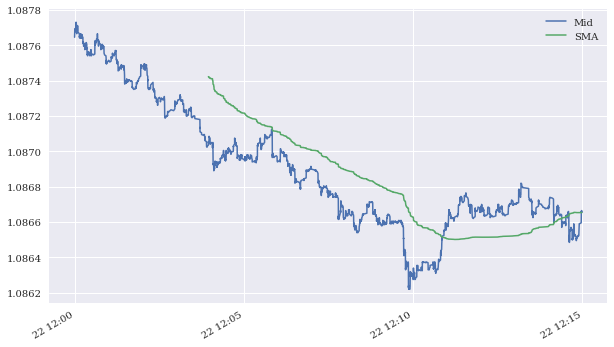

In [14]:
sub[['Mid', 'SMA']].plot(figsize=(10, 6), lw=1.5);

## Retrieving Candles Data

In [15]:
from fxcmpy import fxcmpy_candles_data_reader as cdr

In [16]:
print(cdr.get_available_symbols())

('AUDCAD', 'AUDCHF', 'AUDJPY', 'AUDNZD', 'CADCHF', 'EURAUD', 'EURCHF', 'EURGBP', 'EURJPY', 'EURUSD', 'GBPCHF', 'GBPJPY', 'GBPNZD', 'GBPUSD', 'GBPCHF', 'GBPJPY', 'GBPNZD', 'NZDCAD', 'NZDCHF', 'NZDJPY', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDJPY')


In [17]:
start = dt.datetime(2020, 6, 1)
stop = dt.datetime(2020, 7, 1)

`period` must be one of `m1`, `H1` or `D1`

In [18]:
period = 'H1'

In [19]:
candles = cdr('EURUSD', start, stop, period)

In [20]:
data = candles.get_data()

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 600 entries, 2020-05-31 21:00:00 to 2020-07-03 20:00:00
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   BidOpen   600 non-null    float64
 1   BidHigh   600 non-null    float64
 2   BidLow    600 non-null    float64
 3   BidClose  600 non-null    float64
 4   AskOpen   600 non-null    float64
 5   AskHigh   600 non-null    float64
 6   AskLow    600 non-null    float64
 7   AskClose  600 non-null    float64
dtypes: float64(8)
memory usage: 42.2 KB


In [22]:
data[data.columns[:4]].tail()

,BidOpen,BidHigh,BidLow,BidClose
2020-07-03 16:00:00,1.12431,1.12448,1.12356,1.12418
2020-07-03 17:00:00,1.12418,1.12449,1.12397,1.12430
2020-07-03 18:00:00,1.12430,1.12465,1.12408,1.12440
2020-07-03 19:00:00,1.12440,1.12455,1.12388,1.12442
2020-07-03 20:00:00,1.12442,1.12512,1.12388,1.12434


In [23]:
data[data.columns[4:]].tail()

,AskOpen,AskHigh,AskLow,AskClose
2020-07-03 16:00:00,1.12433,1.12450,1.12358,1.12417
2020-07-03 17:00:00,1.12417,1.12455,1.12406,1.12435
2020-07-03 18:00:00,1.12435,1.12470,1.12413,1.12456
2020-07-03 19:00:00,1.12456,1.12463,1.12396,1.12455
2020-07-03 20:00:00,1.12455,1.12539,1.12445,1.12493


In [24]:
data['MidClose'] = data[['BidClose', 'AskClose']].mean(axis=1)

In [25]:
data['SMA1'] = data['MidClose'].rolling(30).mean()
data['SMA2'] = data['MidClose'].rolling(100).mean()

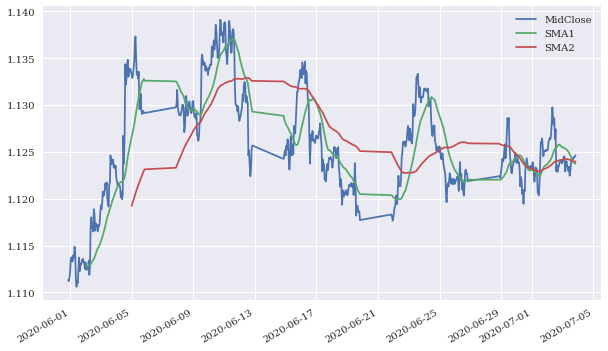

In [26]:
data[['MidClose', 'SMA1', 'SMA2']].plot(figsize=(10, 6));

## Connecting to the API

In [27]:
import fxcmpy

In [28]:
fxcmpy.__version__

'1.2.6'

In [31]:
%time api = fxcmpy.fxcmpy(config_file='../../../data/pyalgo.cfg')

|ERROR|2020-11-24 10:44:44,907|FXCM reject req trading/update_subscriptions with status 524 and msg <!DOCTYPE html>
<!--[if lt IE 7]> <html class="no-js ie6 oldie" lang="en-US"> <![endif]-->
<!--[if IE 7]>    <html class="no-js ie7 oldie" lang="en-US"> <![endif]-->
<!--[if IE 8]>    <html class="no-js ie8 oldie" lang="en-US"> <![endif]-->
<!--[if gt IE 8]><!--> <html class="no-js" lang="en-US"> <!--<![endif]-->
<head>
<meta http-equiv="refresh" content="0">

<title>api-demo.fxcm.com | 524: A timeout occurred</title>
<meta charset="UTF-8" />
<meta http-equiv="Content-Type" content="text/html; charset=UTF-8" />
<meta http-equiv="X-UA-Compatible" content="IE=Edge,chrome=1" />
<meta name="robots" content="noindex, nofollow" />
<meta name="viewport" content="width=device-width,initial-scale=1" />
<link rel="stylesheet" id="cf_styles-css" href="/cdn-cgi/styles/main.css" type="text/css" media="screen,projection" />


</head>
<body>
<div id="cf-wrapper">

    

    <div id="cf-error-details" c

CPU times: user 7.26 s, sys: 2.74 s, total: 10 s
Wall time: 1min 46s


In [30]:
instruments = api.get_instruments()

NameError: name 'api' is not defined

In [ ]:
print(instruments)

## Retrieving Historical Data

In [ ]:
candles = api.get_candles('USD/JPY', period='D1', number=10)

In [ ]:
candles[candles.columns[:4]]

In [ ]:
candles[candles.columns[4:]]

In [ ]:
start = dt.datetime(2019, 1, 1)
end = dt.datetime(2020, 7, 1)

In [ ]:
candles = api.get_candles('EUR/GBP', period='D1',
                          start=start, stop=end)

In [ ]:
candles.info()

The parameter `period` must be one of `m1, m5, m15, m30, H1, H2, H3, H4, H6, H8, D1, W1` or `M1`.

In [ ]:
candles = api.get_candles('EUR/USD', period='m1', number=250)

In [ ]:
candles

In [ ]:
candles['askclose'].plot(figsize=(10, 6));

## Streaming Data

In [ ]:
def output(data, dataframe):
    print('%3d | %s | %s | %6.5f, %6.5f' 
          % (len(dataframe), data['Symbol'],
             pd.to_datetime(int(data['Updated']), unit='ms'), 
             data['Rates'][0], data['Rates'][1]))

In [ ]:
api.subscribe_market_data('EUR/USD', (output,))

In [ ]:
api.get_last_price('EUR/USD')

In [ ]:
api.unsubscribe_market_data('EUR/USD')

## Placing Orders

In [ ]:
api.get_open_positions()

In [ ]:
order = api.create_market_buy_order('EUR/USD', 100)

In [ ]:
sel = ['tradeId', 'amountK', 'currency',
       'grossPL', 'isBuy']

In [ ]:
api.get_open_positions()[sel]

In [ ]:
order = api.create_market_buy_order('EUR/GBP', 50)

In [ ]:
api.get_open_positions()[sel]

In [ ]:
order = api.create_market_sell_order('EUR/USD', 25)

In [ ]:
order = api.create_market_buy_order('EUR/GBP', 50)

In [ ]:
api.get_open_positions()[sel]

In [ ]:
api.close_all_for_symbol('EUR/GBP')

In [ ]:
api.get_open_positions()[sel]

In [ ]:
api.close_all()

In [ ]:
api.get_open_positions()

## Account Information

In [ ]:
api.get_default_account()

In [ ]:
api.get_accounts().T

<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>

<a href="http://tpq.io" target="_blank">http://tpq.io</a> | <a href="http://twitter.com/dyjh" target="_blank">@dyjh</a> | <a href="mailto:training@tpq.io">training@tpq.io</a>